In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\hp1\Downloads\healthcare_dataset.csv')
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


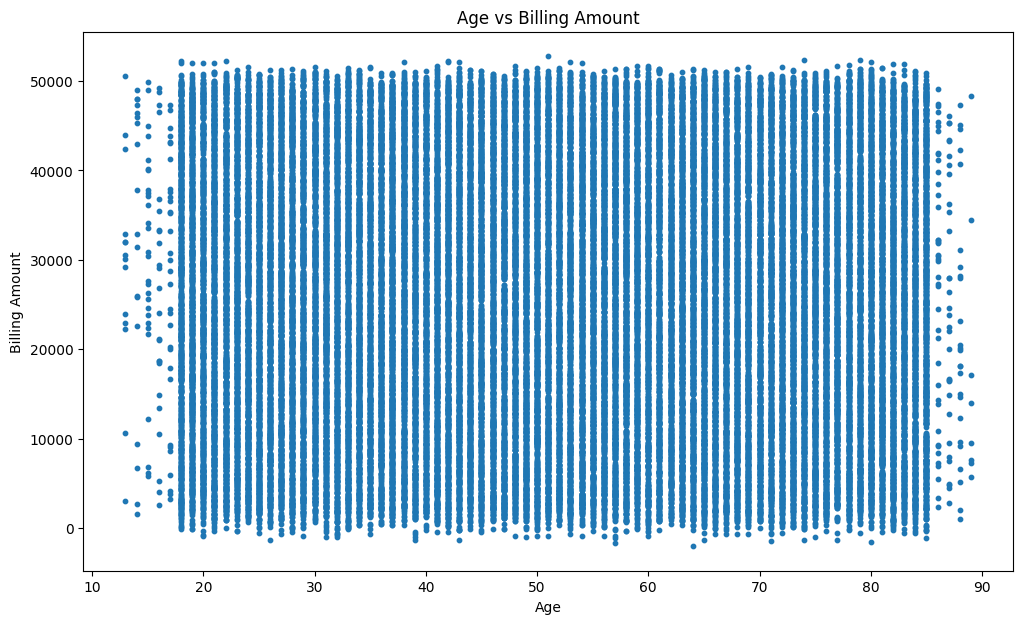

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.scatter(df['Age'], df['Billing Amount'], s=10)

plt.xlabel('Age')
plt.ylabel('Billing Amount')
plt.title('Age vs Billing Amount')

plt.show()

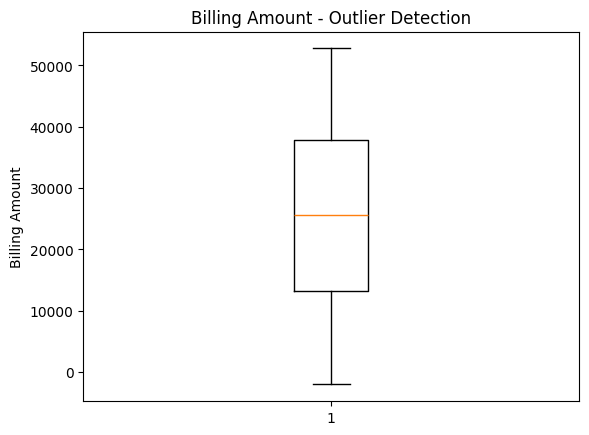

In [3]:
## For seeing outliers
import matplotlib.pyplot as plt

plt.boxplot(df['Billing Amount'])
plt.ylabel('Billing Amount')
plt.title('Billing Amount - Outlier Detection')
plt.show()

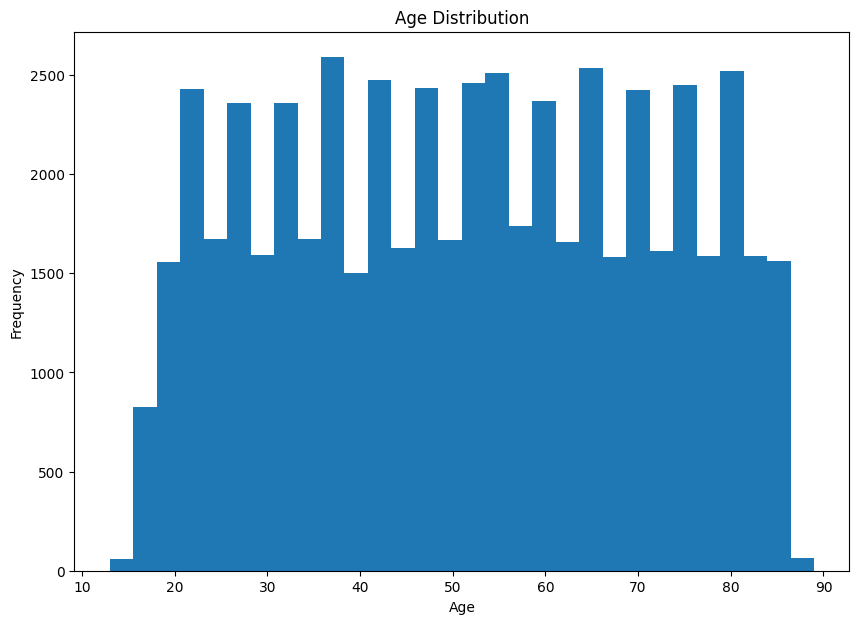

In [4]:
# best for understanding the distribution
plt.figure(figsize=(10, 7))

plt.hist(df['Age'], bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [5]:
from sklearn.ensemble import IsolationForest

In [6]:
df.dtypes

Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

In [7]:
X = df[['Age', 'Billing Amount', 'Room Number']]

from sklearn.ensemble import IsolationForest

clf = IsolationForest(contamination=0.2, random_state=42)

clf.fit(X)

predictions = clf.predict(X)

In [8]:
df['Outlier'] = predictions

In [9]:
df[['Age', 'Billing Amount', 'Room Number', 'Outlier']].head(10)

,Age,Billing Amount,Room Number,Outlier
0,30,18856.281306,328,1
1,62,33643.327287,265,1
2,76,27955.096079,205,1
3,28,37909.782410,450,1
4,43,14238.317814,458,1
5,36,48145.110951,389,1
6,21,19580.872345,389,1
7,20,45820.462722,277,-1
8,82,50119.222792,316,-1
9,58,19784.631062,249,1


In [10]:
predictions

array([1, 1, 1, ..., 1, 1, 1], shape=(55500,))

In [11]:
import numpy as np

index = np.where(predictions < 0)
index

(array([    7,     8,    20, ..., 55483, 55484, 55493], shape=(11100,)),)

In [12]:
X = df[['Age', 'Billing Amount', 'Room Number']]


In [13]:
x = X.values

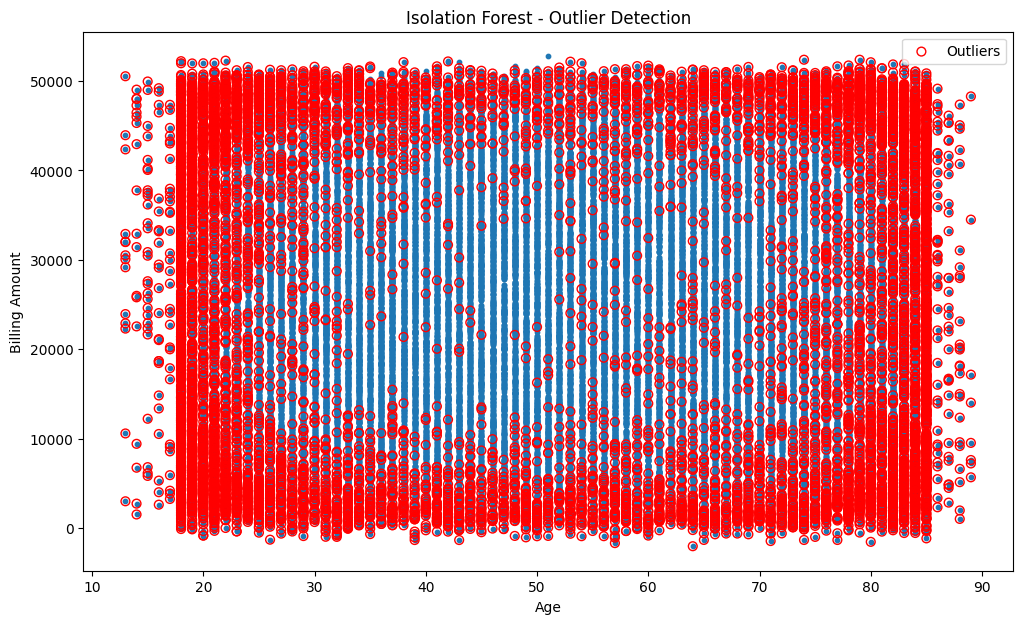

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# All data points
plt.scatter(df['Age'], df['Billing Amount'], s=10)

# Outliers
plt.scatter(
    x[index, 0],
    x[index, 1],
    edgecolors='r',
    facecolors='none',
    s=40,
    label='Outliers'
)

plt.xlabel('Age')
plt.ylabel('Billing Amount')
plt.title('Isolation Forest - Outlier Detection')
plt.legend()
plt.show()

In [15]:
X = df[['Age', 'Billing Amount', 'Room Number']]

from sklearn.ensemble import IsolationForest

clf = IsolationForest(
    contamination=0.2,
    random_state=42
)

clf.fit(X)

predictions = clf.predict(X)

In [16]:
X = df[['Age', 'Billing Amount', 'Room Number']]

from sklearn.ensemble import IsolationForest

clf = IsolationForest(
    contamination=0.2,
    random_state=42
)

clf.fit(X)

predictions = clf.predict(X)

In [17]:
X

,Age,Billing Amount,Room Number
0,30,18856.281306,328
1,62,33643.327287,265
2,76,27955.096079,205
3,28,37909.782410,450
4,43,14238.317814,458
...,...,...,...
55495,42,2650.714952,417
55496,61,31457.797307,316
55497,38,27620.764717,347
55498,43,32451.092358,321


In [18]:
import numpy as np

print("Normal points:", np.sum(predictions == 1))
print("Anomalies:", np.sum(predictions == -1))

Normal points: 44400
Anomalies: 11100


In [19]:
df['Anomaly'] = predictions

In [20]:
df['Anomaly'].value_counts()

Anomaly
 1    44400
-1    11100
Name: count, dtype: int64

In [21]:
anomalies = df[df['Anomaly'] == -1]

anomalies.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Outlier,Anomaly
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive,-1,-1
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal,-1,-1
20,tIMOTHY burNs,67,Female,A-,Asthma,2023-06-28,Krista Smith,Jones LLC,Blue Cross,42.514589,115,Elective,2023-07-02,Aspirin,Normal,-1,-1
31,JAmES pattERson,23,Female,A+,Arthritis,2019-11-03,Kristina Frazier,Cruz-Santiago,UnitedHealthcare,25835.323595,108,Urgent,2019-11-29,Penicillin,Abnormal,-1,-1
36,DEnIse ToRRES,33,Male,AB+,Diabetes,2019-10-14,Laura Myers,LLC Martin,Aetna,4397.776995,481,Urgent,2019-10-19,Paracetamol,Inconclusive,-1,-1


In [22]:
anomalies.shape

(11100, 17)